# 16. Verifikasi Mapping Kode View (1–5)

Sebelum membangun view classifier (frontal / lateral kanan / lateral kiri / maxillary / mandibular),
kita perlu memastikan dulu **mapping digit terakhir nama file** di dataset OMNI benar-benar sesuai
dengan asumsi berikut:

| kode | hipotesis view |
|---|---|
| 1 | frontal |
| 2 | lateral kanan |
| 3 | lateral kiri |
| 4 | maxillary (oklusal rahang atas) |
| 5 | mandibular (oklusal rahang bawah) |

Notebook ini mengambil **satu visit (pasien + tanggal) yang punya kelima kode lengkap**,
menampilkan kelima fotonya berdampingan, supaya bisa dicek visual satu-satu sebelum dipakai
untuk generate label otomatis pada seluruh dataset.

> Semua langkah berikutnya (data prep, training view classifier) bergantung pada mapping ini benar.
> Kalau ada kode yang ternyata salah, perbaiki `VIEW_MAP` di sel berikut sebelum lanjut ke notebook berikutnya.

In [5]:
import os
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image

# --- path dataset OMNI (folder sibling dari IOTN-AC di ~/OMNI) ---
OMNI_IMG_DIR = os.path.expanduser('~/OMNI/data/OMNI_YOLO/images')
SPLITS = ['train', 'val', 'test']
assert os.path.isdir(OMNI_IMG_DIR), f'Folder tidak ditemukan: {OMNI_IMG_DIR}'

# --- HIPOTESIS mapping kode (digit terakhir nama file) -> nama view ---
# ubah di sini kalau hasil verifikasi visual menunjukkan mapping berbeda
VIEW_MAP = {
    '1': 'frontal',
    '2': 'lateral_kanan',
    '3': 'lateral_kiri',
    '4': 'maxillary',
    '5': 'mandibular',
}

In [6]:
def cari_visit_lengkap(pilih_ke=0):
    """Cari visit (pasien+tanggal) yang punya kelima kode view (1-5) lengkap.
    pilih_ke: index visit ke berapa yang diambil kalau mau ganti contoh (0 = pertama ditemukan)."""
    visit_files = defaultdict(dict)
    for split in SPLITS:
        for p in glob(os.path.join(OMNI_IMG_DIR, split, '*.JPG')):
            stem = os.path.splitext(os.path.basename(p))[0]
            kode = stem[-1]
            visit_id = stem[:-1]
            if kode in VIEW_MAP:
                visit_files[visit_id][kode] = p
    lengkap = [(vid, f) for vid, f in visit_files.items() if set(f.keys()) == set(VIEW_MAP.keys())]
    if not lengkap:
        raise RuntimeError('Tidak ditemukan visit dengan kelima kode view lengkap.')
    print(f'Jumlah visit dengan 5 view lengkap: {len(lengkap)}')
    return lengkap[pilih_ke]

VISIT_ID, FILES = cari_visit_lengkap(pilih_ke=0)
print('Contoh visit dipakai untuk verifikasi:', VISIT_ID)
for k in sorted(FILES):
    print(f'  kode {k} ({VIEW_MAP[k]:14s}) -> {FILES[k]}')

Jumlah visit dengan 5 view lengkap: 701
Contoh visit dipakai untuk verifikasi: 20210720210128
  kode 1 (frontal       ) -> /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images/train/202107202101281.JPG
  kode 2 (lateral_kanan ) -> /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images/train/202107202101282.JPG
  kode 3 (lateral_kiri  ) -> /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images/train/202107202101283.JPG
  kode 4 (maxillary     ) -> /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images/train/202107202101284.JPG
  kode 5 (mandibular    ) -> /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images/train/202107202101285.JPG


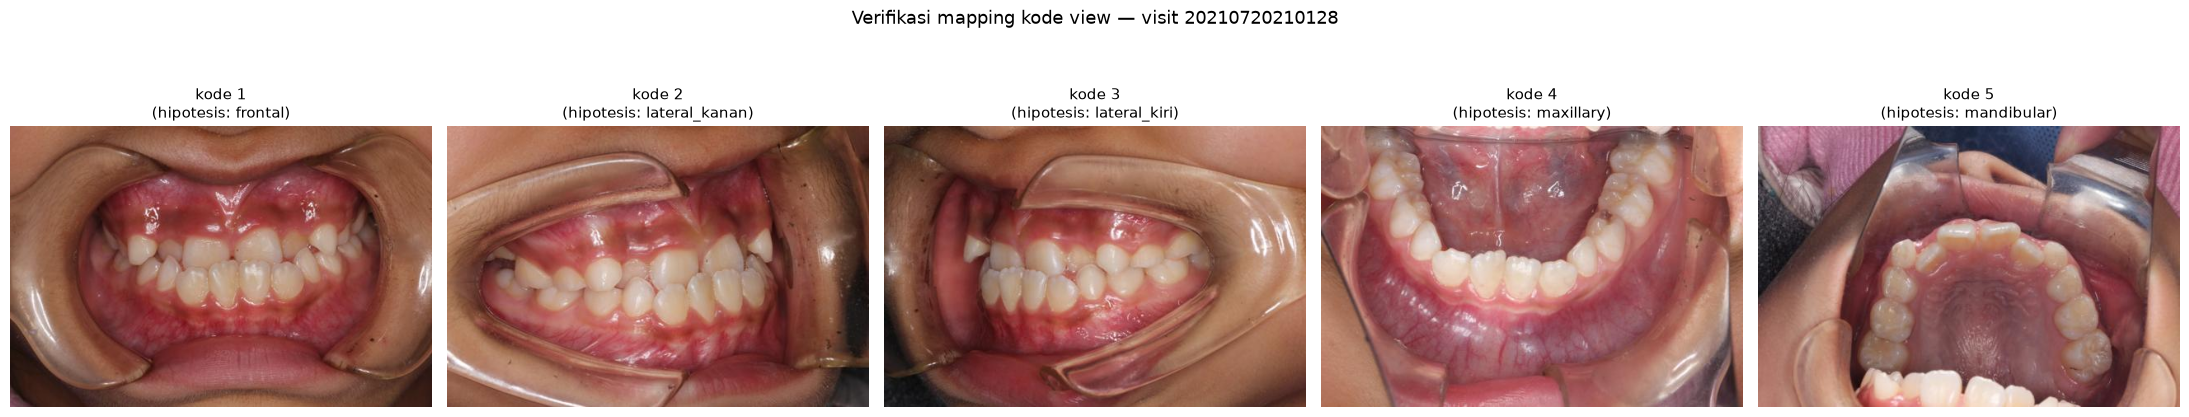


Cek visual satu per satu terhadap hipotesis:
  kode 1 -> harus FRONTAL (gigi menutup rapat, tampak depan)
  kode 2 -> harus LATERAL KANAN (retraktor menampakkan sisi kanan pasien)
  kode 3 -> harus LATERAL KIRI (retraktor menampakkan sisi kiri pasien)
  kode 4 -> harus OKLUSAL RAHANG ATAS / maxillary (lengkung atas, biasanya tanpa lidah kelihatan)
  kode 5 -> harus OKLUSAL RAHANG BAWAH / mandibular (lengkung bawah, lidah biasanya ikut kelihatan)

Kalau ada yang tidak cocok, ganti isi VIEW_MAP di sel sebelumnya lalu jalankan ulang notebook ini.


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, kode in zip(axes, sorted(FILES)):
    img = Image.open(FILES[kode]).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'kode {kode}\n(hipotesis: {VIEW_MAP[kode]})', fontsize=11)
    ax.axis('off')
fig.suptitle(f'Verifikasi mapping kode view — visit {VISIT_ID}', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCek visual satu per satu terhadap hipotesis:')
print('  kode 1 -> harus FRONTAL (gigi menutup rapat, tampak depan)')
print('  kode 2 -> harus LATERAL KANAN (retraktor menampakkan sisi kanan pasien)')
print('  kode 3 -> harus LATERAL KIRI (retraktor menampakkan sisi kiri pasien)')
print('  kode 4 -> harus OKLUSAL RAHANG ATAS / maxillary (lengkung atas, biasanya tanpa lidah kelihatan)')
print('  kode 5 -> harus OKLUSAL RAHANG BAWAH / mandibular (lengkung bawah, lidah biasanya ikut kelihatan)')
print('\nKalau ada yang tidak cocok, ganti isi VIEW_MAP di sel sebelumnya lalu jalankan ulang notebook ini.')

Jumlah visit dengan 5 view lengkap: 701
Contoh visit kedua: 20223720230203


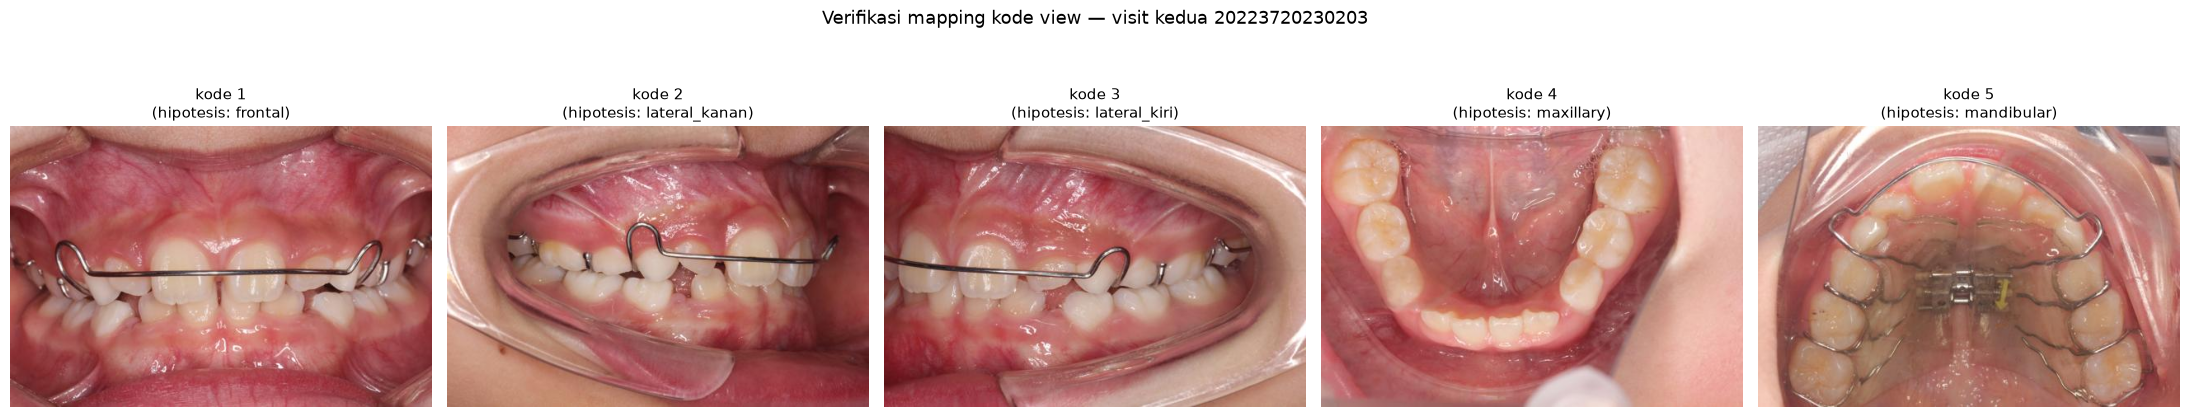

In [8]:
# --- opsional: cek contoh visit KEDUA untuk silang-periksa ---
# (berguna terutama untuk membedakan kanan vs kiri / maxillary vs mandibular
#  yang kadang ambigu kalau cuma dilihat dari satu contoh)
VISIT_ID_2, FILES_2 = cari_visit_lengkap(pilih_ke=1)
print('Contoh visit kedua:', VISIT_ID_2)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, kode in zip(axes, sorted(FILES_2)):
    img = Image.open(FILES_2[kode]).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'kode {kode}\n(hipotesis: {VIEW_MAP[kode]})', fontsize=11)
    ax.axis('off')
fig.suptitle(f'Verifikasi mapping kode view — visit kedua {VISIT_ID_2}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Bangun dataset 5-view (train/val/test) berdasarkan ID pasien di `Grade AC by Team.xlsx`

Prinsipnya: **pool semua foto OMNI (lintas folder train/val/test aslinya)**, lalu **split
train/val/test ditentukan oleh sheet di file label AC**, bukan oleh folder fisik OMNI
(sudah dicek: 0 pasien yang overlap antar-sheet Train/Val/Test di file label, jadi split-nya bersih).

Untuk tiap visit (pasien+tanggal) yang ada di file label, ambil kelima foto view-nya
(kode 1–5) dari OMNI, lalu salin ke struktur folder baru:

```
data/view5/
  train/frontal/…  train/lateral_kanan/…  train/lateral_kiri/…  train/maxillary/…  train/mandibular/…
  val/...
  test/...
```

Visit yang fotonya tidak lengkap 5 view tetap dipakai — cuma slot view yang memang tidak
ada fotonya yang dilewati (dilaporkan di ringkasan, bukan dibuang diam-diam).

In [9]:
import shutil
from collections import Counter
from openpyxl import load_workbook

# --- path ---
PROJECT_ROOT = os.path.expanduser('~/IOTN-AC')
LABEL_FILE = os.path.join(PROJECT_ROOT, 'data', 'labels', 'Grade AC by Team.xlsx')
OUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'view5')
SPLITS = ['train', 'val', 'test']          # nama sheet di LABEL_FILE (case-sensitive: Train/Val/Test)
SHEET_TO_SPLIT = {'Train': 'train', 'Val': 'val', 'Test': 'test'}

assert os.path.exists(LABEL_FILE), f'File label tidak ditemukan: {LABEL_FILE}'
print('Label file  :', LABEL_FILE)
print('OMNI images :', OMNI_IMG_DIR)
print('Output      :', OUT_DIR)

Label file  : /Users/rdrusdiati/IOTN-AC/data/labels/Grade AC by Team.xlsx
OMNI images : /Users/rdrusdiati/OMNI/data/OMNI_YOLO/images
Output      : /Users/rdrusdiati/IOTN-AC/data/view5


In [10]:
def visit_split_dari_xlsx():
    """Baca sheet Train/Val/Test di LABEL_FILE, kembalikan {visit_id: split}.
    visit_id = nama file tanpa digit kode terakhir & tanpa ekstensi."""
    wb = load_workbook(LABEL_FILE, data_only=True)
    visit_split = {}
    tabrakan = []
    for sheet_name, split in SHEET_TO_SPLIT.items():
        if sheet_name not in wb.sheetnames:
            print(f'  [!] sheet {sheet_name} tidak ditemukan di file, dilewati')
            continue
        ws = wb[sheet_name]
        head = [str(c.value).strip() if c.value is not None else '' for c in ws[1]]
        i_nama = head.index('Nama File')
        for row in ws.iter_rows(min_row=2, values_only=True):
            nama = row[i_nama]
            if not nama or not str(nama).strip().lower().endswith('.jpg'):
                continue
            stem = str(nama).strip().rsplit('.', 1)[0]
            visit_id = stem[:-1]                      # buang digit kode view terakhir
            if visit_id in visit_split and visit_split[visit_id] != split:
                tabrakan.append(visit_id)
            visit_split[visit_id] = split
    if tabrakan:
        raise RuntimeError(f'Ada visit_id yang muncul di lebih dari satu split, cek dulu: {tabrakan[:10]}')
    return visit_split

VISIT_SPLIT = visit_split_dari_xlsx()
cnt = Counter(VISIT_SPLIT.values())
print('Jumlah visit per split (dari xlsx):', dict(cnt))

Jumlah visit per split (dari xlsx): {'train': 374, 'val': 75, 'test': 106}


In [11]:
def indeks_omni_images():
    """Scan seluruh foto OMNI (lintas folder train/val/test fisiknya), kembalikan
    ((visit_id, kode) -> path) dan daftar kode di luar VIEW_MAP (anomali) yang ditemukan."""
    idx = {}
    anomali = []
    for split in SPLITS:
        for p in glob(os.path.join(OMNI_IMG_DIR, split, '*.JPG')):
            stem = os.path.splitext(os.path.basename(p))[0]
            kode = stem[-1]; visit_id = stem[:-1]
            if kode not in VIEW_MAP:
                anomali.append(os.path.basename(p))
                continue
            idx[(visit_id, kode)] = p
    return idx, anomali

OMNI_INDEX, KODE_ANOMALI = indeks_omni_images()
print(f'Total foto valid ter-index (kode 1-5): {len(OMNI_INDEX)}')
print(f'Foto dengan kode anomali (dilewati)  : {len(KODE_ANOMALI)}')
if KODE_ANOMALI:
    print('  contoh:', KODE_ANOMALI[:10])

Total foto valid ter-index (kode 1-5): 4146
Foto dengan kode anomali (dilewati)  : 20
  contoh: ['201903201807109.JPG', '201903201807108.JPG', '2020252020101110.JPG', '202025202010117.JPG', '201823201808186.JPG', '201823201808187.JPG', '202025202010116.JPG', '2019032018071010.JPG', '202025202010118.JPG', '201823201808188.JPG']


In [12]:
def bangun_dataset_view5(dry_run=False):
    """Salin foto ke data/view5/{split}/{view}/ berdasarkan VISIT_SPLIT + OMNI_INDEX.
    dry_run=True: cuma hitung, tidak menyalin file (buat cek dulu sebelum eksekusi asli)."""
    ringkasan = {s: Counter() for s in SPLITS}
    visit_lengkap = {s: 0 for s in SPLITS}
    visit_bolong = {s: [] for s in SPLITS}

    for visit_id, split in VISIT_SPLIT.items():
        kode_ada = []
        for kode, nama_view in VIEW_MAP.items():
            src = OMNI_INDEX.get((visit_id, kode))
            if src is None:
                continue
            kode_ada.append(kode)
            dst_dir = os.path.join(OUT_DIR, split, nama_view)
            dst = os.path.join(dst_dir, os.path.basename(src))
            if not dry_run:
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src, dst)
            ringkasan[split][nama_view] += 1
        if len(kode_ada) == 5:
            visit_lengkap[split] += 1
        else:
            hilang = sorted(set(VIEW_MAP) - set(kode_ada))
            visit_bolong[split].append((visit_id, [VIEW_MAP[k] for k in hilang]))

    return ringkasan, visit_lengkap, visit_bolong

# jalankan dulu dry_run=True untuk lihat ringkasannya sebelum benar-benar menyalin file
RINGKASAN, VISIT_LENGKAP, VISIT_BOLONG = bangun_dataset_view5(dry_run=True)

In [13]:
print(f'{"split":6s} ' + ' '.join(f'{v:>14s}' for v in VIEW_MAP.values()) + '   lengkap-5  bolong')
print('-' * 100)
for s in SPLITS:
    baris = ' '.join(f'{RINGKASAN[s][v]:>14d}' for v in VIEW_MAP.values())
    print(f'{s:6s} {baris}   {VISIT_LENGKAP[s]:>9d}  {len(VISIT_BOLONG[s]):>6d}')

print('\nContoh visit yang bolong (maks 10 per split):')
for s in SPLITS:
    for visit_id, hilang in VISIT_BOLONG[s][:10]:
        print(f'  [{s}] {visit_id} -> tidak ada: {hilang}')

print('\nKalau angkanya sudah masuk akal, jalankan sel berikut dengan dry_run=False untuk benar-benar menyalin file.')

split         frontal  lateral_kanan   lateral_kiri      maxillary     mandibular   lengkap-5  bolong
----------------------------------------------------------------------------------------------------
train             373            346            346            317            326         292      82
val                75             69             71             67             69          63      12
test              106             99            100             92             93          87      19

Contoh visit yang bolong (maks 10 per split):
  [train] 20180120201229 -> tidak ada: ['lateral_kanan']
  [train] 20182720180828 -> tidak ada: ['mandibular']
  [train] 20182820210627 -> tidak ada: ['maxillary']
  [train] 20184420190213 -> tidak ada: ['lateral_kiri']
  [train] 20184420190517 -> tidak ada: ['lateral_kiri']
  [train] 20184420190619 -> tidak ada: ['lateral_kanan', 'maxillary']
  [train] 20184420190805 -> tidak ada: ['lateral_kiri']
  [train] 20186720180829 -> tidak ada: ['l

In [14]:
# --- EKSEKUSI ASLI: salin file ke data/view5/ ---
RINGKASAN, VISIT_LENGKAP, VISIT_BOLONG = bangun_dataset_view5(dry_run=False)
total = sum(sum(RINGKASAN[s].values()) for s in SPLITS)
print(f'Selesai menyalin {total} foto ke {OUT_DIR}')
for s in SPLITS:
    print(f'  {s}: ' + ', '.join(f'{v}={RINGKASAN[s][v]}' for v in VIEW_MAP.values()))

Selesai menyalin 2549 foto ke /Users/rdrusdiati/IOTN-AC/data/view5
  train: frontal=373, lateral_kanan=346, lateral_kiri=346, maxillary=317, mandibular=326
  val: frontal=75, lateral_kanan=69, lateral_kiri=71, maxillary=67, mandibular=69
  test: frontal=106, lateral_kanan=99, lateral_kiri=100, maxillary=92, mandibular=93
